In [2]:
import scipy.stats as stats
import numpy as np
import sys
sys.path.append('..')
from utils import get_wer_values
import pandas as pd

## Data from eval AI for test set

In [2]:
llama_1b_4_gram = [
    9.23,   # Seed 1
    9.04,   # Seed 2
    9.095,  # Seed 3
    9.825,  # Seed 4
    9.338,  # Seed 5
    9.446,  # Seed 6
    9.257,  # Seed 7
    9.379,  # Seed 8
    9.717,  # Seed 9
    9.405   # Seed 10
]

# The single Baseline value to test against
baseline_ref = 9.76

np.save("saved_data/main_results", llama_1b_4_gram)

## Val Set Baseline

In [3]:
# Val WER
val_score = [
    14.10,  # seed0
    13.90,  # seed1
    14.41,  # seed2
    14.61,  # seed3
    13.90,  # seed4
    14.14,  # seed5
    14.28,  # seed6
    14.19,  # seed7
    13.90,  # seed8
    14.26   # seed9
]


np.save("saved_data/val_scores", val_score)

### Ablation #1: Calling LLM Only Once at the End of Decoding
Only appply LLM rescoring once trial has finished.

In [4]:
wer, csv_files = get_wer_values("../../results/b2t_24", "no_delayed_fusion")
print(len(wer))
np.save("saved_data/no_delayed_fusion_ablation", wer)

10


### Ablation #2: Using Non-Finetuned LLM
Use LLM that has not been fine-tuned to do next-word prediction on training set.

In [5]:
wer, csv_files = get_wer_values("../../results/b2t_24", "no_finetuning")
print(len(wer))
np.save("saved_data/no_finetuning_ablation", wer)

10


### Ablation #3: Remove multiple phoneme variants
Each word only has a single phoneme sequence.

In [6]:
wer, csv_files = get_wer_values("../../results/b2t_24", "no_variants")
print(len(wer))
np.save("saved_data/no_variants_ablation", wer)

10


### Ablation #4: llama-3B finetuned
Use the finetuned 3B model for delayed fusion.

In [7]:
wer, csv_files = get_wer_values("../../results/b2t_24", "llama_3b")
print(len(wer))
np.save("saved_data/llama_3b_ablation", wer)

10


In [8]:
wer, csv_files = get_wer_values("../../results/transformer", "llama_1b")
print(len(wer))
np.save("saved_data/b2t24_combined_transformer", wer)

FileNotFoundError: [Errno 2] No such file or directory: '../../results/transformer'

In [3]:
wer_unidirectional = [11.46, 11.60, 11.11, 11.97, 11.40]
np.save("saved_data/transformer_unidirectional", wer_unidirectional)

wer_chunked_chunk10 = [11.02, 12.15, 11.69, 11.42, 11.26]
np.save("saved_data/transformer_demichunked_10", wer_chunked_chunk10)

wer_chunked_chunk1 = [10.91, 12.20, 11.60, 11.33, 11.37]
np.save("saved_data/transformer_demichunked_1", wer_chunked_chunk1)

In [ ]:
wer_unidirectional = [11.46, 11.60, 11.11, 11.97, 11.40, 11.99, 12.55, 11.84, 12.28, 11.68]
np.save("saved_data/transformer_unidirectional", wer_unidirectional)


np.array([11.19, 11.33, 11.22, 11.69, 11.31, 11.33, 12.37, 11.77, 12.33, 11.53])


In [4]:
wer_unidirectional = [8.0525, 8.3096, 7.7277, 7.7953, 7.6329, 7.8224, 8.7291, 8.2690, 8.5261, 7.9442]
np.save("saved_data/transformer_unidirectional_20_test", wer_unidirectional)

In [3]:
wer_unidirectional_val = [11.46, 11.62, 11.04, 11.89, 11.37, 11.93, 12.55, 11.88, 12.37, 11.64]
np.save("saved_data/transformer_unidirectional_7.5_val", wer_unidirectional_val)

In [5]:
wer_unidirectional_test = [8.0795, 8.3096, 7.7277, 7.7953, 7.6059, 7.8224, 8.7156, 8.2825, 8.5261, 7.9442]
np.save("saved_data/transformer_unidirectional_7.5_test", wer_unidirectional_test)

In [5]:
wer_unidirectional_test_tuned = [7.9442, 8.4179, 7.6871, 7.8495, 7.5652, 7.7547, 8.5532, 8.1743, 8.1337, 7.7953]
np.save("saved_data/transformer_unidirectional_20_test_tuned", wer_unidirectional_test_tuned)

In [5]:
# Generative Approach Results

# Unidirectional b2t24'
llama_8b_b2t24_uni = [5.305, 5.156, 5.183, 4.966, 5.129, 5.102, 4.899, 4.980, 4.845, 5.034]
llama_3b_b2t24_uni = [5.440, 5.575, 5.575, 5.359, 5.575, 5.657, 5.345, 5.535, 5.318, 5.494]


# Bidirectional b2t24'
llama_8b_b2t24_bi = [5.088, 4.912, 5.115, 5.169, 4.912, 5.115, 4.926, 4.966, 4.872, 5.020]
llama_3b_b2t24_bi = [5.075, 5.034, 4.926, 5.102, 5.020, 4.885, 4.899, 4.966, 4.790, 5.169]


# Unidirectional b2t25'
llama_8b_b2t25_uni_private = [2.934, 2.526, 2.887, 2.746, 2.840, 2.542, 2.950, 2.934, 2.919, 2.856]
llama_8b_b2t25_uni_public = [2.545, 2.545, 2.545, 2.333, 2.303, 2.545, 2.181, 2.181, 2.454, 2.424]


llama_3b_b2t25_uni_private = [2.871, 2.715, 2.683, 2.997, 3.044, 2.809, 3.060, 2.919, 2.856, 2.997]
llama_3b_b2t25_uni_public = [2.393, 2.606, 2.515, 2.090, 2.424, 2.606, 2.545, 2.393, 2.424, 2.606]


# Bidirectional b2t25'
llama_8b_b2t25_bi_private = [2.385, 2.385, 2.354, 2.463, 2.354, 2.385, 2.354, 2.322, 2.244, 2.401]
llama_8b_b2t25_bi_public = [2.000, 2.181, 2.060, 2.060, 2.333, 2.030, 2.030, 1.878, 2.181, 2.090]

llama_3b_b2t25_bi_private = [2.416, 2.291, 2.463, 2.510, 2.605, 2.479, 2.416, 2.432, 2.589, 2.385]
llama_3b_b2t25_bi_public = [2.212, 2.484, 2.212, 2.393, 2.272, 2.242, 2.242, 2.181, 2.121, 2.242]


# Unidirectional b2t24' WFST
llama_8b_b2t24_uni_wfst = [5.629, 5.724, 5.684, 5.697, 5.778, 5.508, 5.792, 5.724, 5.738, 5.832]


# Bidirectional b2t24' WFST
llama_8b_b2t24_bi_wfst = [5.684, 5.440, 5.548, 5.291,  5.643, 5.102, 5.020, 5.278, 5.237, 5.697]


# Unidirectional b2t25' WFST
llama_8b_b2t25_uni_private_wfst = [2.777, 2.746, 2.699, 2.809, 2.824, 2.730, 2.793, 2.715, 2.824, 2.652]
llama_8b_b2t25_uni_public_wfst = [2.878, 2.787, 2.727, 2.606, 2.606, 2.666, 2.666, 2.606, 2.757, 2.757]


# Bidirectional b2t25' WFST
llama_8b_b2t25_bi_private_wfst = [2.369, 2.448, 2.401, 2.369, 2.479, 2.510, 2.322, 2.385, 2.510, 2.212]
llama_8b_b2t25_bi_public_wfst = [2.424, 2.363, 2.393, 2.393, 2.545, 2.424, 2.303, 2.393, 2.424, 2.484]



In [12]:
llama_8b_b2t24_bi = np.array([5.088, 4.912, 5.115, 5.169, 4.912, 5.115, 4.926, 4.966, 4.872, 5.020])
llama_8b_b2t25_bi_private = np.array([2.385, 2.385, 2.354, 2.463, 2.354, 2.385, 2.354, 2.322, 2.244, 2.401])
llama_8b_b2t25_bi_public = np.array([2.000, 2.181, 2.060, 2.060, 2.333, 2.030, 2.030, 1.878, 2.181, 2.090])

print(np.mean(llama_8b_b2t24_bi), np.mean(llama_8b_b2t25_bi_private), np.mean(llama_8b_b2t25_bi_public))

5.0095 2.3647 2.0843


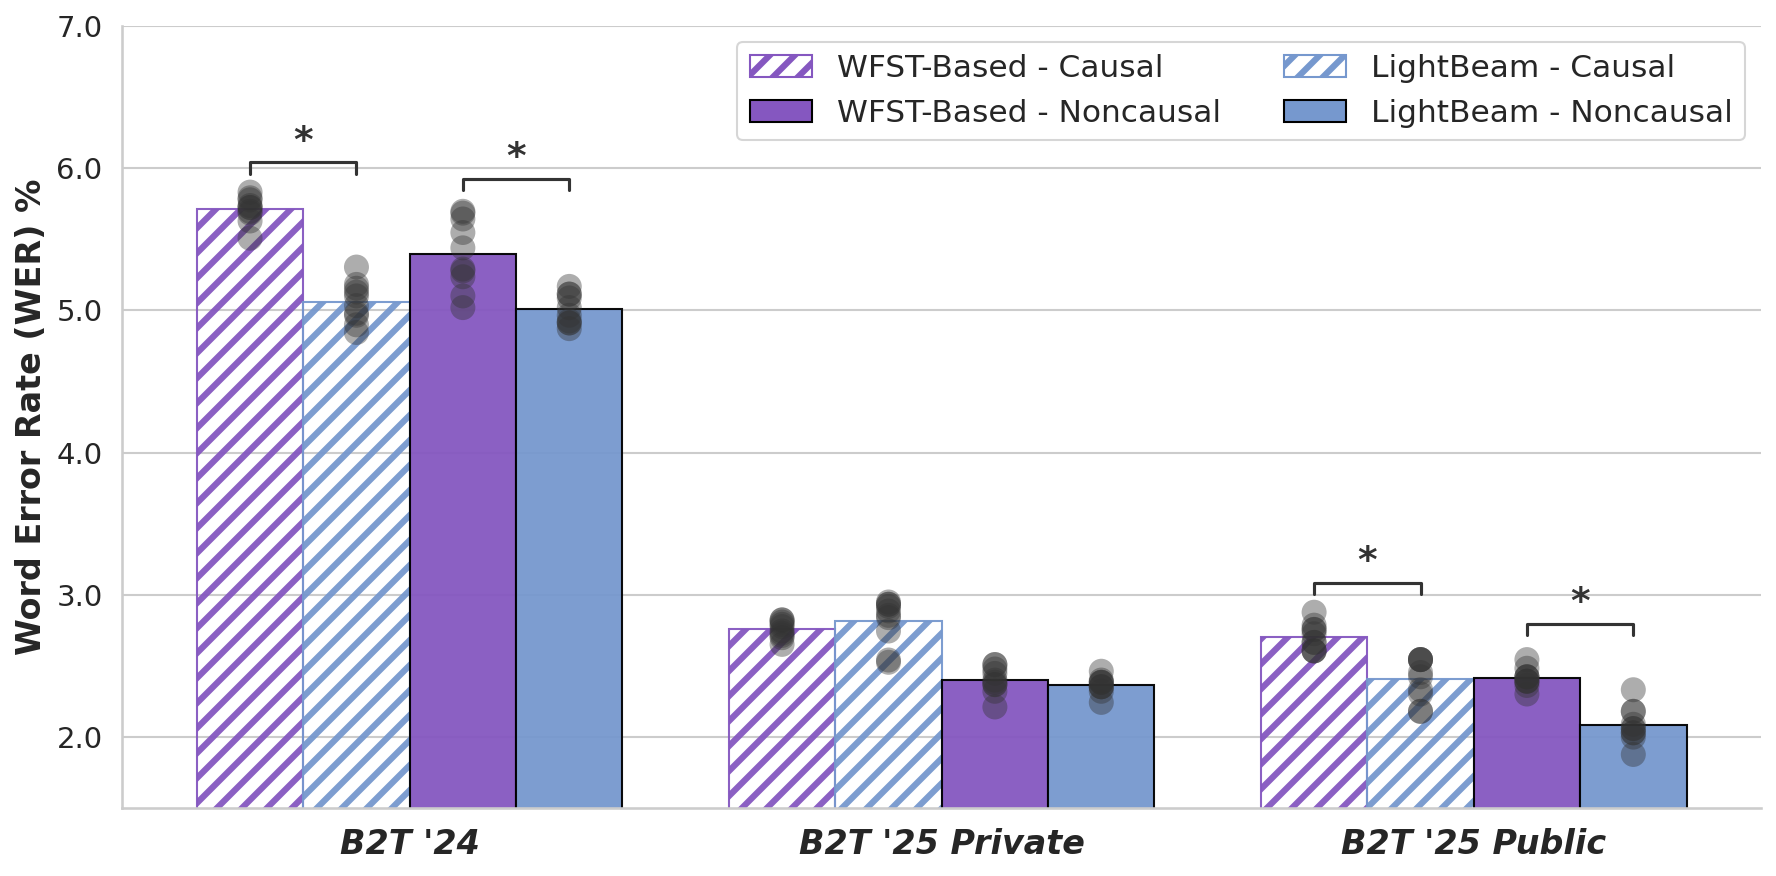

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import matplotlib as mpl


data_8b = {
    "B2T '24": {
        "WFST-Based_uni": llama_8b_b2t24_uni_wfst,
        "LightBeam_uni":  llama_8b_b2t24_uni,
        "WFST-Based_bi":  llama_8b_b2t24_bi_wfst,
        "LightBeam_bi":   llama_8b_b2t24_bi,
        
    },
    "B2T '25 Private": {
        "WFST-Based_uni": llama_8b_b2t25_uni_private_wfst,
        "LightBeam_uni":  llama_8b_b2t25_uni_private,
        "WFST-Based_bi":  llama_8b_b2t25_bi_private_wfst,
        "LightBeam_bi":   llama_8b_b2t25_bi_private,
        
    },
    "B2T '25 Public": {
        "WFST-Based_uni": llama_8b_b2t25_uni_public_wfst,
        "LightBeam_uni":  llama_8b_b2t25_uni_public,
        "WFST-Based_bi":  llama_8b_b2t25_bi_public_wfst,
        "LightBeam_bi":   llama_8b_b2t25_bi_public,
    }
}

# 1. Processing Data to include Directionality
def process_data_v2(data_dict):
    rows = []
    for group, methods in data_dict.items():
        for full_name, values in methods.items():
            # Split key into Method and Direction (e.g., LightBeam and uni)
            method, direction = full_name.split('_')
            for val in values:
                rows.append({
                    "Group": group, 
                    "Method": method, 
                    "Direction": direction,
                    "Full_Key": full_name,
                    "WER": val
                })
    return pd.DataFrame(rows)

df_8b = process_data_v2(data_8b)
# --- 1. Global Hatch Configuration ---
mpl.rcParams['hatch.linewidth'] = 3.0  # Thicker stripes

# --- 2. Data Processing ---
def process_data_v2(data_dict):
    rows = []
    for group, methods in data_dict.items():
        for full_name, values in methods.items():
            method, direction = full_name.split('_')
            for val in values:
                rows.append({
                    "Group": group,
                    "Method": method,
                    "Direction": direction,
                    "Full_Key": full_name,
                    "WER": val
                })
    return pd.DataFrame(rows)

df_8b = process_data_v2(data_8b)

# --- 3. Aesthetics Configuration ---
sns.set_theme(style="whitegrid")
palette = {"LightBeam": "#7698ce", "WFST-Based": "#8557c0"}
methods_order = ["WFST-Based_uni","LightBeam_uni", "WFST-Based_bi", "LightBeam_bi"]

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# --- 4. Plotting the Bars ---
sns.barplot(
    data=df_8b, x="Group", y="WER", hue="Full_Key",
    hue_order=methods_order, 
    palette=[palette["LightBeam"], palette["LightBeam"], 
             palette["WFST-Based"], palette["WFST-Based"]],
    alpha=0.95, edgecolor="black", width=0.8, ax=ax, errorbar=None
)

# # --- 5. EXPLICIT BAR-BY-BAR MODIFICATION ---
# # Matplotlib draws all 3 bars for Hue 1, then all 3 bars for Hue 2, etc.
for i in range(0, 3):
    bar = ax.patches[i]
    bar.set_facecolor("none")  
    bar.set_edgecolor(palette["WFST-Based"]) 
    bar.set_hatch('//')

# B. LightBeam Unidirectional (Indices 3, 4, 5)
for i in range(3, 6):
    bar = ax.patches[i]
    bar.set_facecolor("none")  
    bar.set_edgecolor(palette["LightBeam"]) 
    bar.set_hatch('//')

# C. WFST-Based Bidirectional (Indices 6, 7, 8)
for i in range(6, 9):
    bar = ax.patches[i]
    bar.set_facecolor(palette["WFST-Based"])
    bar.set_edgecolor("black") 

# D. LightBeam Bidirectional (Indices 9, 10, 11)
for i in range(9, 12):
    bar = ax.patches[i]
    bar.set_facecolor(palette["LightBeam"])
    bar.set_edgecolor("black")


# --- 6. Plotting the Dots ---
sns.stripplot(
    data=df_8b, x="Group", y="WER", hue="Full_Key",
    hue_order=methods_order, dodge=True, 
    palette=["#333333", "#333333", "#333333", "#333333"],
    alpha=0.4, size=12, jitter=0, legend=False, ax=ax
)

# --- 7. STATISTICAL SIGNIFICANCE BRACKETS ---
def draw_bracket(patch1, patch2, text="*", offset=0.4, h=0.08, lw=1.5, color='#333333', star_size=18, star_pad=0.02):
    """
    offset:    How high above the tallest bar the bracket's legs start. 
               (Lowered from 0.35 to 0.15 to bring it closer to the bars).
    h:         The height of the bracket's vertical legs (the 'drop' down to the bar).
    lw:        The line width (thickness) of the bracket.
    color:     The color of both the line and the star. (Changed to dark gray to match dots).
    star_size: The font size of the asterisk.
    star_pad:  The tiny gap between the flat top of the bracket and the bottom of the asterisk.
    """
    
    # Find the horizontal center of each bar
    x1 = patch1.get_x() + patch1.get_width() / 2
    x2 = patch2.get_x() + patch2.get_width() / 2
    
    # Calculate the Y height using the new smaller offset
    y = max(patch1.get_height(), patch2.get_height()) + offset 
    
    # Draw the bracket using lines
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color=color)
    
    # Place the star directly above the center line
    ax.text((x1+x2)/2, y + h + star_pad, text, ha='center', va='bottom', 
            color=color, fontsize=star_size, fontweight='bold')

# Group 0 (B2T'24)
draw_bracket(ax.patches[0], ax.patches[3], offset=0.25) # WFST_uni vs LightBeam_uni
draw_bracket(ax.patches[6], ax.patches[9], offset=0.45) # WFST_bi vs LightBeam_bi

# Group 1 (B2T'25 Private)
# draw_bracket(ax.patches[1], ax.patches[4])  # WFST_uni vs LightBeam_uni
# draw_bracket(ax.patches[7], ax.patches[10]) # WFST_bi vs LightBeam_bi

# Group 2 (B2T'25 Public)
draw_bracket(ax.patches[2], ax.patches[5], offset=0.3)   # WFST_uni vs LightBeam_uni
draw_bracket(ax.patches[8], ax.patches[11], offset=0.3)  # WFST_bi vs LightBeam_bi

# --- 8. Formatting ---
ax.set_ylabel("Word Error Rate (WER) %", fontsize=16, fontweight='bold')
ax.set_xlabel("")

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.set_ylim(1.5, 6.5)
ax.set_yticks([2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
ax.tick_params(axis='both', labelsize=14)
plt.setp(ax.get_xticklabels(), fontsize=16, fontweight='bold', fontstyle='italic')
ax.xaxis.grid(False)

# --- 9. Custom Legend ---
legend_elements = [
    Patch(facecolor="none", edgecolor=palette["WFST-Based"], hatch='//', label='WFST-Based - Causal'),
    Patch(facecolor=palette["WFST-Based"], edgecolor='black', label='WFST-Based - Noncausal'),
    Patch(facecolor="none", edgecolor=palette["LightBeam"], hatch='//', label='LightBeam - Causal'),
    Patch(facecolor=palette["LightBeam"], edgecolor='black', label='LightBeam - Noncausal'),
]
ax.legend(handles=legend_elements, loc='upper right', ncol=2, fontsize=15)
sns.despine()
plt.tight_layout()
plt.savefig("generative_corrector.pdf")
plt.show()

In [ ]:
np.save("../generative_results/b2t_25_8b_generative_public", llama_8b_b2t25_uni_public)
np.save("../generative_results/b2t_25_8b_generative_private", llama_8b_b2t25_uni_private)

In [ ]:
np.save("../generative_results/b2t_24_8b_bi_generative", llama_8b_b2t24_bi)
np.save("../generative_results/b2t_24_3b_bi_generative", llama_3b_b2t24_bi)

In [4]:
np.save("../generative_results/b2t_25_8b_bi_generative_public", llama_8b_b2t25_bi_public)
np.save("../generative_results/b2t_25_3b_bi_generative_public", llama_3b_b2t25_bi_public)

np.save("../generative_results/b2t_25_8b_bi_generative_private", llama_8b_b2t25_bi_private)
np.save("../generative_results/b2t_25_3b_bi_generative_private", llama_3b_b2t25_bi_private)

In [ ]:
rtf_24_seed_0 = [(1, 0.665), (5, 0.207), (10, 0.145), (15, 0.125), (20, 0.114)]
rtf_25_seed_0 = [(1, 0.1417), (5, 0.1426), (10, 0.1415), (15, 0.1441), (20, 0.1495)]

wer_24_seed_0 = [(1, 0.358), (5, 0.100), (10, 0.067), (15, 0.056), (20, 0.050)]
wer_25_seed_0 = [(1, 0.0640), (5, 0.0656), (10, 0.0652), (15, 0.0650), (20, 0.0668)]


In [ ]:
rtf_25 = [0.358, 0.100, 0.067, 0.056, 0.050]
wer_25 = [0.0640, 0.0656, 0.0652, 0.0650, 0.0668]

In [ ]:
rtf_24_seed_0 = [(1, 0.665), (5, 0.207), (10, 0.145), (15, 0.125), (20, 0.114)]
rtf_24_seed_1 = [(1, ), (5, ), (10, ), (15, ), (20, 0.167)]
rtf_24_seed_2 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_3 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_4 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_5 = [(1, ), (5, ), (10, ), (15, ), (20, 0.178)]
rtf_24_seed_6 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_7 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_8 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_9 = [(1, ), (5, ), (10, ), (15, ), (20, )]

rtf_25_seed_1 = [(1, 0.358), (5, 0.100), (10, 0.067), (15, 0.056), (20, 0.050)]
rtf_24_seed_2 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_3 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_4 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_5 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_6 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_7 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_8 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_9 = [(1, ), (5, ), (10, ), (15, ), (20, )]
rtf_24_seed_10 = [(1, ), (5, ), (10, ), (15, ), (20, )]


rtf_24_seed_0_75 = 
rtf_25_seed_0_20 = 

In [3]:
wer_24_seed_0 = [(1, 0.1417), (5, 0.1426), (10, 0.1415), (15, 0.1441), (20, 0.1495)]
wer_24_seed_1 = [(1, 0.1406), (5, 0.1377), (10, 0.1397), (15, 0.1428), (20, 0.1448)]
wer_24_seed_2 = [(1, 0.1402), (5, 0.1395), (10, 0.1426), (15, 0.1433), (20, 0.1455)]
wer_24_seed_3 = [(1, 0.1451), (5, 0.1435), (10, 0.1470), (15, 0.1495), (20, 0.1486)]
wer_24_seed_4 = [(1, 0.1381), (5, 0.1406), (10, 0.1397), (15, 0.1415), (20, 0.1437)]
wer_24_seed_5 = [(1, 0.1399), (5, 0.1382), (10, 0.1430), (15, 0.1444), (20, 0.1486)]
wer_24_seed_6 = [(1, 0.1408), (5, 0.1395), (10, 0.1426), (15, 0.1462), (20, 0.1468)]
wer_24_seed_7 = [(1, 0.1404), (5, 0.1390), (10, 0.1422), (15, 0.1439), (20, 0.1471)]
wer_24_seed_8 = [(1, 0.1355), (5, 0.1368), (10, 0.1395), (15, 0.1415), (20, 0.1435)]
wer_24_seed_9 = [(1, 0.1406), (5, 0.1406), (10, 0.1426), (15, 0.1442), (20, 0.1475)]

wer_25_seed_1  = [(1, 0.0640), (5, 0.0656), (10, 0.0652), (15, 0.0650), (20, 0.0668)]
wer_25_seed_2  = [(1, 0.0620), (5, 0.0622), (10, 0.0624), (15, 0.0620), (20, 0.0627)]
wer_25_seed_3  = [(1, 0.0640), (5, 0.0633), (10, 0.0626), (15, 0.0635), (20, 0.0636)]
wer_25_seed_4  = [(1, 0.0604), (5, 0.0609), (10, 0.0614), (15, 0.0623), (20, 0.0626)]
wer_25_seed_5  = [(1, 0.0620), (5, 0.0636), (10, 0.0627), (15, 0.0624), (20, 0.0636)]
wer_25_seed_6  = [(1, 0.0632), (5, 0.0624), (10, 0.0633), (15, 0.0627), (20, 0.0637)]
wer_25_seed_7  = [(1, 0.0668), (5, 0.0676), (10, 0.0670), (15, 0.0677), (20, 0.0675)]
wer_25_seed_8  = [(1, 0.0622), (5, 0.0633), (10, 0.0638), (15, 0.0641), (20, 0.0642)]
wer_25_seed_9  = [(1, 0.0611), (5, 0.0611), (10, 0.0615), (15, 0.0617), (20, 0.0625)]
wer_25_seed_10 = [(1, 0.0665), (5, 0.0663), (10, 0.0675), (15, 0.0663), (20, 0.0679)]

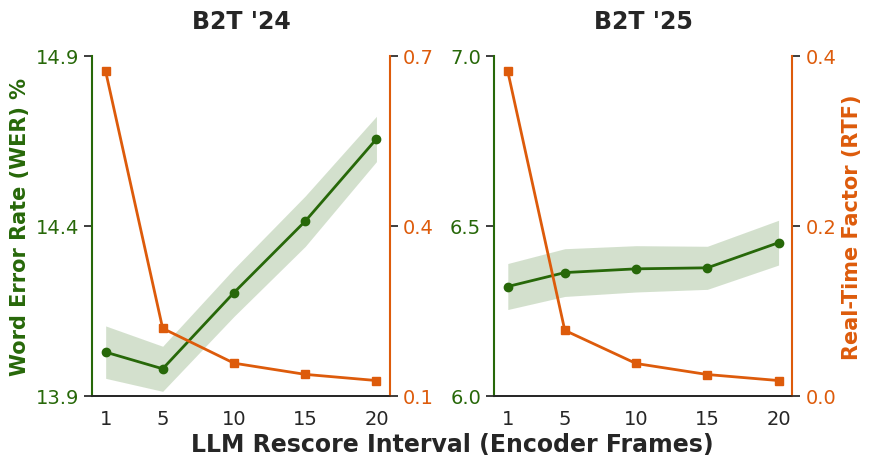

In [4]:
import matplotlib.pyplot as plt
            
import seaborn as sns

import matplotlib.ticker as ticker

import numpy as np
from scipy import stats


# 1. Data Setup

x = [1, 5, 10, 15, 20]


# Aggregate b2t24 across 10 seeds → shape (10, 5)
all_wer_24_seeds = [
wer_24_seed_0, wer_24_seed_1, wer_24_seed_2,wer_24_seed_3, wer_24_seed_4,
wer_24_seed_5, wer_24_seed_6, wer_24_seed_7, wer_24_seed_8, wer_24_seed_9,
]
wer_24_arr  = np.array([[v * 100 for _, v in seed] for seed in all_wer_24_seeds])
wer_24_mean = wer_24_arr.mean(axis=0)
wer_24_sem  = stats.sem(wer_24_arr, axis=0)   # std/sqrt(10)

all_wer_25_seeds = [
wer_25_seed_1, wer_25_seed_2,wer_25_seed_3, wer_25_seed_4, wer_25_seed_5,
wer_25_seed_6, wer_25_seed_7, wer_25_seed_8, wer_25_seed_9, wer_25_seed_10
]
wer_25_arr  = np.array([[v * 100 for _, v in seed] for seed in all_wer_25_seeds])
wer_25_mean = wer_25_arr.mean(axis=0)
wer_25_sem  = stats.sem(wer_25_arr, axis=0)   # std/sqrt(10)


# b2t25 and RTF unchanged
rtf_24 = [0.665, 0.207, 0.145, 0.125, 0.114]
rtf_25 = [0.358, 0.100, 0.067, 0.056, 0.050]

# 2. Aesthetics Setup
sns.set_theme(style="white")
color_wer, color_rtf = "#276809", "#dd5b0b"

fig, (ax1_l, ax2_l) = plt.subplots(1, 2, figsize=(10, 5))

def setup_minimalist_plot(ax_left, x_vals, wer_vals, rtf_vals, title_str, is_first, is_last, wer_sem=None, wer_ylim=None):
     wer_vals = np.array(wer_vals)

     # WER line + optional SEM band
     ax_left.plot(x_vals, wer_vals, color=color_wer,marker='o', linestyle='-', linewidth=2)
     if wer_sem is not None:
         ax_left.fill_between(x_vals,wer_vals - wer_sem,wer_vals + wer_sem, color=color_wer, alpha=0.2,linewidth=0)

     if wer_ylim is not None:
         ax_left.set_ylim(wer_ylim)

     ax_left.tick_params(axis='y', labelcolor=color_wer, labelsize=14)
     ax_left.tick_params(axis='x', labelsize=14)

     # RTF Twin axis
     ax_right = ax_left.twinx()
     ax_right.plot(x_vals, rtf_vals, color=color_rtf, marker='s', linestyle='-', linewidth=2)
     ax_right.tick_params(axis='y', labelcolor=color_rtf, labelsize=14)

     # Spines
     for ax in [ax_left, ax_right]:
         ax.spines['top'].set_visible(False)
         ax.grid(False)
     ax_left.spines['bottom'].set_visible(True)
     ax_right.spines['bottom'].set_visible(True)
     ax_left.spines['left'].set_color(color_wer)
     ax_left.spines['left'].set_linewidth(1.5)
     ax_right.spines['right'].set_color(color_rtf)
     ax_right.spines['right'].set_linewidth(1.5)
     ax_left.spines['right'].set_visible(False)
     ax_right.spines['left'].set_visible(False)

     if is_first:
         ax_left.set_ylabel('Word Error Rate (WER) %', fontsize=15, color=color_wer, fontweight='bold')
     if is_last:
         ax_right.set_ylabel('Real-Time Factor (RTF)', fontsize=15, color=color_rtf, fontweight='bold')

     ax_left.yaxis.set_major_locator(ticker.LinearLocator(numticks=3))
     ax_right.yaxis.set_major_locator(ticker.LinearLocator(numticks=3))
     ax_left.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
     ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
     ax_left.set_title(title_str, fontsize=17, fontweight='bold', pad=20)
     ax_left.set_xticks(x_vals)

# 3. Generate Subplots
setup_minimalist_plot(ax1_l, x, wer_24_mean, rtf_24, "B2T '24", is_first=True, is_last=False, wer_sem=wer_24_sem, wer_ylim=(13.9, 14.9))
setup_minimalist_plot(ax2_l, x, wer_25_mean, rtf_25, "B2T '25", is_first=False, is_last=True, wer_sem=wer_25_sem, wer_ylim=(6.0, 7.0))
fig.supxlabel('LLM Rescore Interval (Encoder Frames)',fontsize=17, fontweight='bold', x=0.46, y=0.08)
plt.subplots_adjust(wspace=0.35, left=0.1, right=0.8,bottom=0.2)
plt.savefig("wer_vs_rtf.pdf")
plt.show()

In [1]:
import json

with open("/home/lionelhu/brainaudio/results/per_results/neurips_b2t_24_chunked_unidirectional_transformer_5to20_sec.json") as f:
        b2t_24_source = json.load(f)

with open("/home/lionelhu/brainaudio/results/per_results/neurips_b2t_25_causal_transformer_v4_prob_1.json") as f:
        b2t_25_source = json.load(f)


b2t_24_lc = {}
for key in b2t_24_source.keys():
    cand_per = list(b2t_24_source[key].values())
    new_key = key[16:]
    if new_key != "full":
        b2t_24_lc[float(new_key)] = cand_per

b2t_25_lc = {}
for key in b2t_25_source.keys():
    cand_per = list(b2t_25_source[key].values())
    new_key = key[16:]
    if new_key != "full":
        b2t_25_lc[float(new_key)] = cand_per



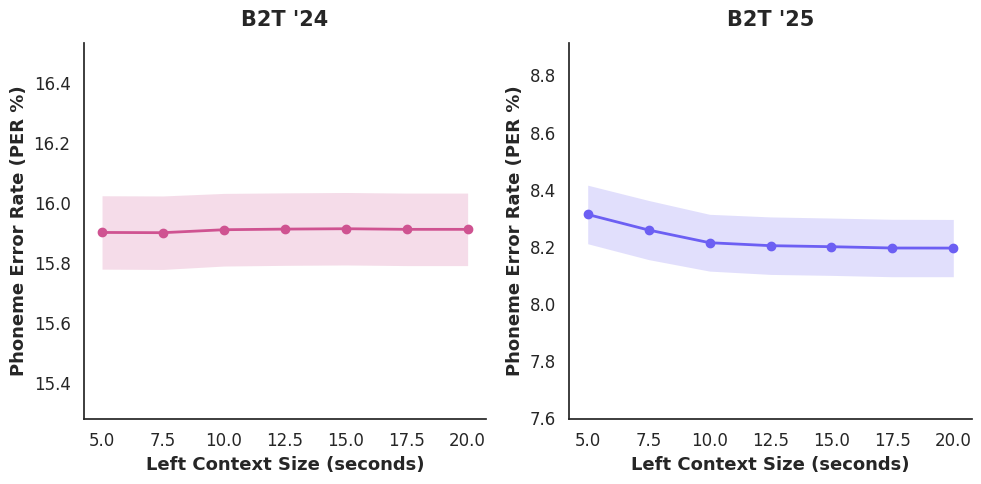

In [2]:
import numpy as np                                          
import matplotlib.pyplot as plt                             
import matplotlib.ticker as ticker                          
from scipy import stats                                     
import seaborn as sns
                                                            
sns.set_theme(style="white")                                
                                                            
color_24 = "#cf5391"                                        
color_25 = "#6c5ff3"                                        
                                                            
def compute_stats(lc_dict):                                 
    """Returns sorted (x, mean, sem) arrays from            
{context_size: [per_seed_values]}."""                       
    xs = sorted(lc_dict.keys())                             
    arr = np.array([lc_dict[x] for x in xs]) * 100         
    means = arr.mean(axis=1)
    sems  = stats.sem(arr, axis=1)
    return np.array(xs), means, sems

x24, mean24, sem24 = compute_stats(b2t_24_lc)
x25, mean25, sem25 = compute_stats(b2t_25_lc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

def plot_single(ax, x, mean, sem, color, title):
    ax.plot(x, mean, color=color, marker='o', linewidth=2)
    ax.fill_between(x, mean - sem, mean + sem, color=color,alpha=0.2, linewidth=0)

    # NEW LOGIC: Calculate limits based on the extreme edges of the error band
    y_lower = (mean - sem).min()
    y_upper = (mean + sem).max()
    # Add a flat 10% padding to the top and bottom of those extremes
    y_range = y_upper - y_lower
    pad = max(y_range * 0.1, 0.5) 
    ax.set_ylim(y_lower - pad, y_upper + pad)

    ax.set_xticks(x)
    ax.tick_params(labelsize=12)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.set_xlabel("Left Context Size (seconds)",fontsize=13, fontweight='bold')
    ax.set_ylabel("Phoneme Error Rate (PER %)", fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_single(ax1, x24, mean24, sem24, color_24, "B2T '24")
plot_single(ax2, x25, mean25, sem25, color_25, "B2T '25")

plt.tight_layout()
plt.savefig("left_context_vs_per.pdf")
plt.show()

In [ ]:
gru_b2t24_3b = np.array([13.81, 13.75, 13.91, 13.93, 13.71, 13.84, 13.88, 13.57, 14.08, 13.75])
mean_gru_b2t24_3b = np.mean(gru_b2t24_3b)
std_gru_b2t24_3b = np.std(gru_b2t24_3b)
rtf_gru_24 = 0.26
vram_gru_24 = 9.82
print(f"GRU24 w/ llama-3.2-3B: mean-{mean_gru_b2t24_3b:.2f}; std-{std_gru_b2t24_3b:.2f}; rtf-{rtf_gru_24}; vram-{vram_gru_24}")

gru_b2t25_3b = np.array([6.22, 6.23, 6.04, 6.10, 6.27, 6.04, 6.53, 6.23, 6.22, 6.50])
mean_gru_b2t25_3b = np.mean(gru_b2t25_3b)
std_gru_b2t25_3b = np.std(gru_b2t25_3b)
rtf_gru_25 = 0.08
vram_gru_25 = 9.64
print(f"GRU25 w/ llama-3.2-3B: mean-{mean_gru_b2t25_3b:.2f}; std-{std_gru_b2t25_3b:.2f}; rtf-{rtf_gru_25}; vram-{vram_gru_25}")

GRU24 w/ llama-3.2-3B: mean - 13.82 std - 0.13 rtf - 0.26
GRU25 w/ llama-3.2-3B: mean - 6.24 std - 0.16 rtf - 0.08


In [11]:
gru_b2t24_1b = np.load("/home/lionelhu/brainaudio/figure_data/b2t_24_results/saved_data/val_scores.npy")
gru_b2t25_1b = np.load("/home/lionelhu/brainaudio/figure_data/b2t_25_results/saved_data/val_scores.npy")

mean_gru_b2t24_1b = np.mean(gru_b2t24_1b)
std_gru_b2t24_1b = np.std(gru_b2t24_1b)

mean_gru_b2t25_1b = np.mean(gru_b2t25_1b)
std_gru_b2t25_1b = np.std(gru_b2t25_1b)

print(mean_gru_b2t24_1b,std_gru_b2t24_1b)
print(mean_gru_b2t25_1b,std_gru_b2t25_1b)

14.169 0.2227756719213296
6.356599999999999 0.14397235845814288


--- Paired T-Test Results ---
Mean A: 13.8230, SEM 0.0442
Mean B: 14.1690, SEM 0.0743
Mean difference (A - B): -0.3460
T-statistic:    -4.29219
P-value:        0.00201

Conclusion: The difference is statistically significant (Reject H0).
A is significantly better than B.


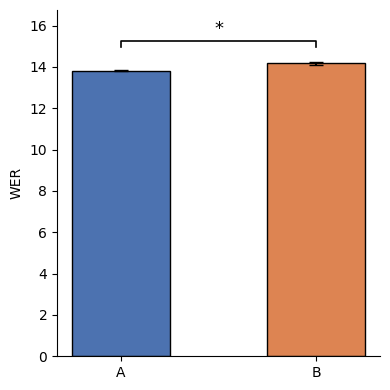

In [8]:
from utils import one_sample_t_test, paired_t_test

t,p = paired_t_test(gru_b2t24_3b, gru_b2t24_1b)


--- Paired T-Test Results ---
Mean A: 6.2380, SEM 0.0530
Mean B: 6.3566, SEM 0.0480
Mean difference (A - B): -0.1186
T-statistic:    -2.13473
P-value:        0.06155

Conclusion: The difference is NOT statistically significant (Fail to reject H0).


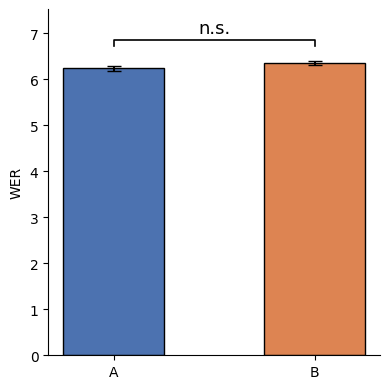

In [9]:
t,p = paired_t_test(gru_b2t25_3b, gru_b2t25_1b)